In [3]:
#Step 1: Data Importing & Cleaning
import pandas as pd

main_df = pd.read_csv("owid_climate_data.csv")
main_df.head()
main_df.index
main_df.columns
main_df.info
main_df.head()
main_df.isnull()

,Country Name,Country Code,Year,CO2 Emissions Per Capita,Annual Temperature Anomaly
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
26177,False,False,False,False,False
26178,False,False,False,False,False
26179,False,False,False,False,False
26180,False,False,False,False,False


In [4]:
main_df.dropna(subset=["CO2 Emissions Per Capita", "Annual Temperature Anomaly"])

,Country Name,Country Code,Year,CO2 Emissions Per Capita,Annual Temperature Anomaly
0,Afghanistan,AFG,1949,0.001992,-2.020418
1,Afghanistan,AFG,1950,0.010837,-2.298886
2,Afghanistan,AFG,1951,0.011625,-1.287201
3,Afghanistan,AFG,1952,0.011468,-1.237078
4,Afghanistan,AFG,1953,0.013123,-1.084867
...,...,...,...,...,...
26177,Zimbabwe,ZWE,2019,0.672040,0.878125
26178,Zimbabwe,ZWE,2020,0.547085,0.229293
26179,Zimbabwe,ZWE,2021,0.645915,0.016838
26180,Zimbabwe,ZWE,2022,0.648761,0.035659


In [5]:
main_df = main_df.dropna(subset=["CO2 Emissions Per Capita", "Annual Temperature Anomaly"]) #Drops any NaN values in these two columns

In [6]:
main_df.head(5)

,Country Name,Country Code,Year,CO2 Emissions Per Capita,Annual Temperature Anomaly
0,Afghanistan,AFG,1949,0.001992,-2.020418
1,Afghanistan,AFG,1950,0.010837,-2.298886
2,Afghanistan,AFG,1951,0.011625,-1.287201
3,Afghanistan,AFG,1952,0.011468,-1.237078
4,Afghanistan,AFG,1953,0.013123,-1.084867


In [16]:
#Step 2 Sets & Functions

#Here I make a set of all countries in the dataset
main_df["Country Name"]
countries = main_df["Country Name"] #Set of Countries
countries.drop_duplicates() #Shows a set of all the countries in the CSV, dropping the dupes of each one
#Make a separate dataframe for country name only
country_name_df = main_df[["Country Name"]].drop_duplicates()
country_name_df = country_name_df.reset_index() #Reseting index for this new DF
country_name_df

#Making a separate dataframe for country name WITH duplicates
country_name_df_unduplicated_df = main_df[["Country Name"]]
country_name_df_unduplicated_df = country_name_df_unduplicated_df.reset_index()
country_name_df_unduplicated_df


,index,Country Name
0,0,Afghanistan
1,1,Afghanistan
2,2,Afghanistan
3,3,Afghanistan
4,4,Afghanistan
...,...,...
14314,26177,Zimbabwe
14315,26178,Zimbabwe
14316,26179,Zimbabwe
14317,26180,Zimbabwe


In [13]:
#Now to make a separate dataframe for year
main_df["Year"]
year_df = main_df[["Year"]]
year_df

,Year
0,1949
1,1950
2,1951
3,1952
4,1953
...,...
26177,2019
26178,2020
26179,2021
26180,2022


In [18]:
#Combining Country_Name and Year into one DF!
country_name_and_year_range_df = country_name_df.join(year_df)
country_name_and_year_range_df

#Combining Country_Name that have the Dupes and Year into one DF!
country_name_unduped_year_range_df = country_name_df_unduplicated_df.join(year_df)
country_name_unduped_year_range_df 

,index,Country Name,Year
0,0,Afghanistan,1949.0
1,1,Afghanistan,1950.0
2,2,Afghanistan,1951.0
3,3,Afghanistan,1952.0
4,4,Afghanistan,1953.0
...,...,...,...
14314,26177,Zimbabwe,NaN
14315,26178,Zimbabwe,NaN
14316,26179,Zimbabwe,NaN
14317,26180,Zimbabwe,NaN


In [19]:
#Function that returns all rows for a given country and year range
def get_country_data(df, country, start_year, end_year):
    filtered_country_and_years = df[(df["Country Name"] == country) &
                                    (df["Year"] >= start_year) &
                                    (df["Year"] <= end_year)]
    return filtered_country_and_years
    
#Practice result
result = get_country_data(country_name_unduped_year_range_df, 'Czechia', 1930, 2020) #I have two country_name_dfs so I can swap between two :)
print(result)

      index Country Name    Year
3396   6084      Czechia  2001.0
3397   6085      Czechia  2002.0
3398   6086      Czechia  2003.0
3399   6087      Czechia  2004.0
3400   6088      Czechia  2005.0
...     ...          ...     ...
3463   6151      Czechia  2016.0
3464   6152      Czechia  2017.0
3465   6153      Czechia  2018.0
3466   6154      Czechia  2019.0
3467   6155      Czechia  2020.0

[69 rows x 3 columns]


In [20]:
#Current DFs
            #main_df
            #country_name_unduped_year_range_df 
            #year_df
            #country_name_df
            #country_year_and_co2_filtered
            #country_co2_and_temperature_df
#Current functions
            #get_country_data

In [21]:
#Step 3 Logical Filtering
main_df

,Country Name,Country Code,Year,CO2 Emissions Per Capita,Annual Temperature Anomaly
0,Afghanistan,AFG,1949,0.001992,-2.020418
1,Afghanistan,AFG,1950,0.010837,-2.298886
2,Afghanistan,AFG,1951,0.011625,-1.287201
3,Afghanistan,AFG,1952,0.011468,-1.237078
4,Afghanistan,AFG,1953,0.013123,-1.084867
...,...,...,...,...,...
26177,Zimbabwe,ZWE,2019,0.672040,0.878125
26178,Zimbabwe,ZWE,2020,0.547085,0.229293
26179,Zimbabwe,ZWE,2021,0.645915,0.016838
26180,Zimbabwe,ZWE,2022,0.648761,0.035659


In [40]:
#Filtering all the countries where CO2 Emissions were ABOVE 10 metric tonnes in 2020
main_df.drop(columns=["Country Code", "Annual Temperature Anomaly"]) #Dropping columns test
country_year_and_co2_filtered = main_df[(main_df["Year"] == 2020) & (main_df["CO2 Emissions Per Capita"] > 10)]
country_year_and_co2_filtered.drop(columns=["Annual Temperature Anomaly", "Country Code"])

,Country Name,Year,CO2 Emissions Per Capita
1729,Australia,2020,15.506062
2272,Bahrain,2020,25.215979
3788,Brunei,2020,24.939121
4447,Canada,2020,13.795024
8826,Faroe Islands,2020,14.426020
12876,Kazakhstan,2020,13.113933
13121,Kuwait,2020,21.739220
14411,Luxembourg,2020,12.806264
15578,Mongolia,2020,11.265909
16476,New Caledonia,2020,17.981370


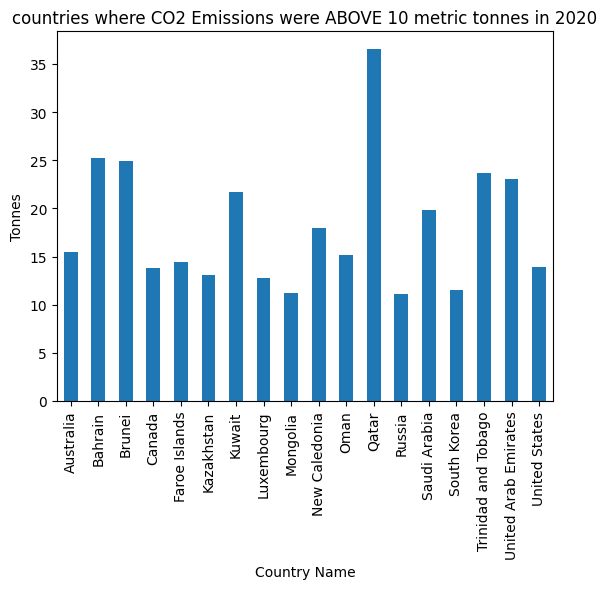

In [42]:
#Displaying the data as a Bar Graph
import matplotlib.pyplot as plt

country_year_and_co2_filtered.plot(x="Country Name", y="CO2 Emissions Per Capita", kind="bar", legend=False)
plt.title("Countries where CO2 Emissions are above 10 metric tonnes in 2020")
plt.ylabel("Tonnes")
plt.show()

In [46]:
#Displaying only the country, co2, and temperature columns
main_df
main_df.drop(columns=["Country Code", "Year"])
country_co2_and_temperature_df = main_df.drop(columns=["Country Code", "Year"])
country_co2_and_temperature_df

,Country Name,CO2 Emissions Per Capita,Annual Temperature Anomaly
0,Afghanistan,0.001992,-2.020418
1,Afghanistan,0.010837,-2.298886
2,Afghanistan,0.011625,-1.287201
3,Afghanistan,0.011468,-1.237078
4,Afghanistan,0.013123,-1.084867
...,...,...,...
26177,Zimbabwe,0.672040,0.878125
26178,Zimbabwe,0.547085,0.229293
26179,Zimbabwe,0.645915,0.016838
26180,Zimbabwe,0.648761,0.035659


In [ ]:
#Create a scatterplot to showcase the relationship between CO2 Emission Per Capita and it's affect on the country's annual temperature but maybe later.
#plt.scatter(country_co2_and_temperature_df["CO2 Emissions Per Capita"], country_co2_and_temperature_df["Annual Temperature Anomaly"])

#for i, country in enumerate(countries):
		plt.text(population[i], energy_use[i], country)
		
		#The above, the name of the country is placed on the value that is on the same index as they are. E.g Nepal is placed on the 30 value of population and 400 energy use.
		
#plt.title("Population vs Energy Use")
#plt.xlabel("Population (millions)")
#plt.ylabel("Energy (TWh)")
#plt.show()



In [ ]:
Current DFs
            #main_df
            #country_name_unduped_year_range_df 
            #year_df
            #country_name_df
            #country_year_and_co2_filtered
            #country_co2_and_temperature_df
#Current functions
            #get_country_data

In [53]:
#Step 4 Probability & Summary Statistics
#Calculating the mean, min, and max of temperature EACH year

#Create a annual temperature + year DF 
main_df.drop(columns=["Country Name", "Country Code", "CO2 Emissions Per Capita",])
annual_temperature_and_year_df = main_df.drop(columns=["Country Name", "Country Code", "CO2 Emissions Per Capita",])
annual_temperature_and_year_df 


,Year,Annual Temperature Anomaly
0,1949,-2.020418
1,1950,-2.298886
2,1951,-1.287201
3,1952,-1.237078
4,1953,-1.084867
...,...,...
26177,2019,0.878125
26178,2020,0.229293
26179,2021,0.016838
26180,2022,0.035659


In [61]:
#Function that calculates the mean of temperature for each year across all countries
def get_mean_temperature_data(df):
    mean_temperature_each_year = df.groupby("Year")["Annual Temperature Anomaly"].mean().reset_index().
    mean_temperature_each_year.columns = ["Year", "Mean Temperature"]
    
    return mean_temperature_each_year

result = get_mean_temperature_data(annual_temperature_and_year_df)
result

,Year,Mean Temperature
0,1940,-1.624415
1,1941,-1.251653
2,1942,-1.368997
3,1943,-1.021218
4,1944,-1.000902
...,...,...
79,2019,0.601391
80,2020,0.580830
81,2021,0.411804
82,2022,0.444629


In [ ]:
#Estimate the probability (as a percentage) that a recorded temperature exceeds 1.5°C

